### 🚀 Asteroid Diameter Prediction – Base Model

This notebook focuses on preparing data and building base models to predict asteroid diameters using various regression techniques. We use a cleaned dataset and apply exploratory data analysis (EDA), outlier handling, and log transformation before training.
- The modeling is done only with rows where 'albedo' and 'diameter' is present.
- This model is not suitable to predict 'diameter' in cases where 'albedo' is missing. 

---

#### 📦 Imports
We import necessary packages for regression modeling, visualization, preprocessing, and evaluation.

In [1]:
import pandas as pd
import numpy as np


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Explainability
import shap

# AutoML
from flaml import AutoML

# Model evaluation & tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#### 📑 Load Cleaned Asteroid Dataset
We load the preprocessed dataset and select rows where both `diameter` and `albedo` values are available, which are important for accurate regression.

In [2]:
asteroid = pd.read_csv('data/asteroid_cleaned.csv', index_col="full_name")

# Extracting rows where diameter and albedo are present
ast_dia = asteroid[asteroid['diameter'].notna()]
ast_dia = ast_dia[ast_dia['albedo'].notna()]

#### 📊 Visualizing Diameter Distribution
We inspect the distribution of the target variable `diameter` using histograms and boxplots.

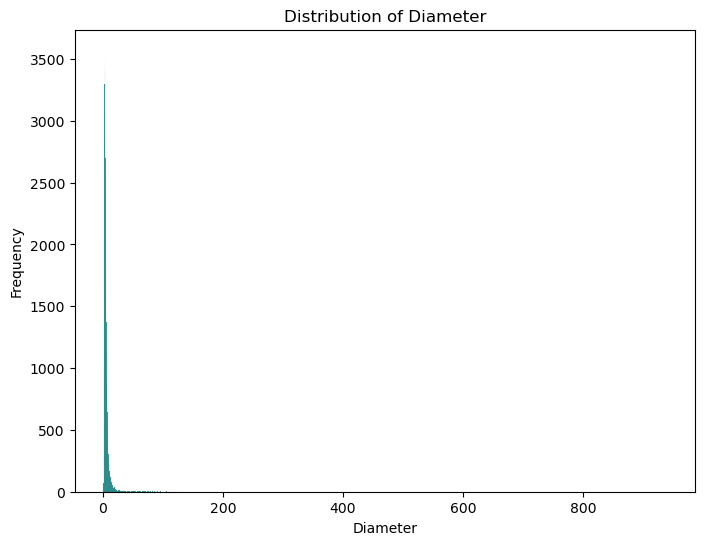

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(ast_dia['diameter'], color='teal')  # kde=True adds a smooth density curve
plt.title('Distribution of Diameter')
plt.xlabel('Diameter')
plt.ylabel('Frequency')
plt.show()

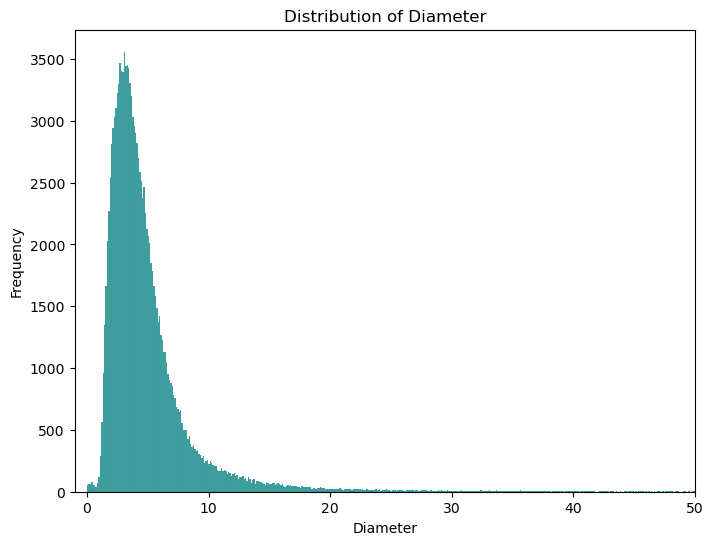

In [4]:
# Zoomed-in view of smaller diameters
plt.figure(figsize=(8, 6))
sns.histplot(ast_dia['diameter'], color='teal')
plt.title('Distribution of Diameter')
plt.xlabel('Diameter')
plt.ylabel('Frequency')
plt.xlim(-1,50)
plt.show()

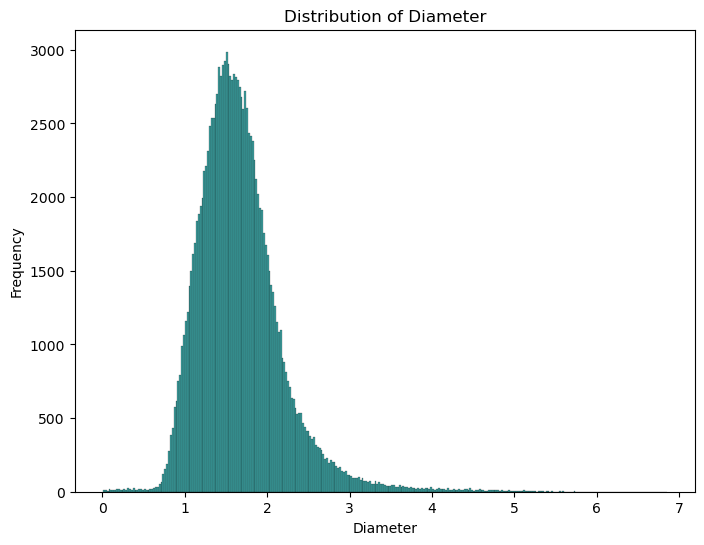

In [5]:
# Log-transformed distribution
plt.figure(figsize=(8, 6))
sns.histplot(np.log1p(ast_dia['diameter']), color='teal')
plt.title('Distribution of Diameter')
plt.xlabel('Diameter')
plt.ylabel('Frequency')
plt.show()

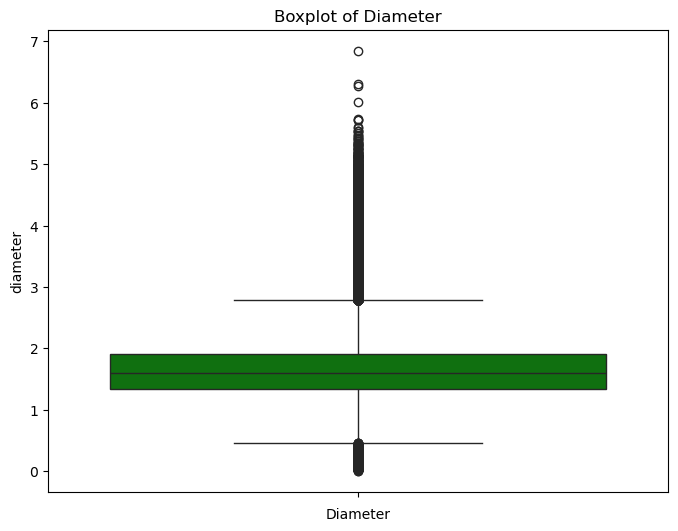

In [6]:
# Boxplot of log-transformed diameter
plt.figure(figsize=(8, 6))
sns.boxplot(np.log1p(ast_dia['diameter']), color='green')
plt.title('Boxplot of Diameter')
plt.xlabel('Diameter')
plt.show()

### 🧹 Outlier Removal and Log Transformation

We apply a log transformation to stabilize variance and reduce skewness. Extreme outliers (above the 99.75th percentile) are filtered out to prevent bias in training.

We then split the dataset into training and testing sets.


In [7]:
# Apply log transformation
y_log = np.log1p(ast_dia['diameter'])

# Remove top 0.25% outliers
upper_bound = np.percentile(y_log, 99.75)
ast_dia_filtered = ast_dia[y_log <= upper_bound]

# Features and target
X_filtered = ast_dia_filtered.drop('diameter', axis=1)
y_filtered = np.log1p(ast_dia_filtered['diameter'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

### 🔍 Regression

We start with a basic linear regression model as a baseline. Then continue on to Random Forest, XGBoost, LightBGM and Catboost. After training, we evaluate performance using both log-transformed and original scale metrics.

In [8]:
# 📈 LINEAR REGRESSION
# Training a simple linear regression model to establish a baseline.

# Initialize and train the model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lin_model.predict(X_test)
y_train_pred = lin_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0160, R² Score: 0.9351
Test  Mean Squared Error: 0.0158, R² Score: 0.9359
Original Scale - Test MSE: 2.6441, R²: 0.9045


In [9]:
# Random forest regression
# Using Random Forest to capture nonlinear relationships and interactions.

# # Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0009, R² Score: 0.9965
Test  Mean Squared Error: 0.0062, R² Score: 0.9750
Original Scale - Test MSE: 0.5663, R²: 0.9795


In [10]:
# XGBOOST REGRESSION
# Applying XGBoost for powerful gradient boosting with regularization.

# Initialize and train XGBRegressor
xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = xgb_reg.predict(X_test)
y_train_pred = xgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

Train Mean Squared Error: 0.0048, R² Score: 0.9804
Test  Mean Squared Error: 0.0062, R² Score: 0.9749
Original Scale - Test MSE: 0.8928, R²: 0.9678


In [11]:
# LightBGM REGRESSION
# Training LightGBM for efficient gradient boosting with fast training.

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(objective='regression', random_state=42)
lgb_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = lgb_reg.predict(X_test)
y_train_pred = lgb_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4693
[LightGBM] [Info] Number of data points in the train set: 108528, number of used features: 31
[LightGBM] [Info] Start training from score 1.663248
Train Mean Squared Error: 0.0058, R² Score: 0.9766
Test  Mean Squared Error: 0.0061, R² Score: 0.9754
Original Scale - Test MSE: 0.5795, R²: 0.9791


In [12]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize and train CatBoost Regressor
cat_reg = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=500
)
cat_reg.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg.predict(X_test)
y_train_pred = cat_reg.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.4843485	total: 161ms	remaining: 2m 40s
500:	learn: 0.0783869	total: 3s	remaining: 2.98s
999:	learn: 0.0753097	total: 5.63s	remaining: 0us
Train MSE: 0.0057, R²: 0.9770
Test  MSE: 0.0058, R²: 0.9764
Original Scale - Test MSE: 0.5228, R²: 0.9811


In [ ]:
# Initialize FLAML AutoML for regression task with a 20-minute time budget
automl = AutoML()

# Fit AutoML on training data using only CatBoost as the estimator, optimizing R² metric
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=1200,  # 20 minutes
    metric="r2",
    estimator_list=["catboost"],  # Focus only on CatBoost
)

[flaml.automl.logger: 06-13 11:19:24] {1752} INFO - task = regression
[flaml.automl.logger: 06-13 11:19:24] {1763} INFO - Evaluation method: holdout
[flaml.automl.logger: 06-13 11:19:25] {1862} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 06-13 11:19:25] {1979} INFO - List of ML learners in AutoML Run: ['catboost']
[flaml.automl.logger: 06-13 11:19:25] {2282} INFO - iteration 0, current learner catboost
[flaml.automl.logger: 06-13 11:19:26] {2417} INFO - Estimated sufficient time budget=104656s. Estimated necessary time budget=105s.
[flaml.automl.logger: 06-13 11:19:26] {2466} INFO -  at 2.6s,	estimator catboost's best error=0.0332,	best estimator catboost's best error=0.0332
[flaml.automl.logger: 06-13 11:19:26] {2282} INFO - iteration 1, current learner catboost
[flaml.automl.logger: 06-13 11:19:37] {2466} INFO -  at 13.6s,	estimator catboost's best error=0.0327,	best estimator catboost's best error=0.0327
[flaml.automl.logger: 06-13 11:19:37] {2282} INFO - iteration 2,

In [ ]:
# Print best estimator name, configuration, and best loss found by AutoML
print(automl.best_estimator)
print(automl.best_config)
print(automl.best_loss)

# Show the actual model selected by AutoML (CatBoost, LightGBM, etc.)
print(automl.model)

catboost
{'early_stopping_rounds': 14, 'learning_rate': 0.08661874652744853, 'n_estimators': 8192}
0.027971287103295994


In [ ]:
# Predict on test set and evaluate performance using R² and RMSE metrics
y_pred = automl.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R2: 0.9712287485899437
RMSE: 0.07792543631659016


c:\Users\aj20j\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Define parameter grid for RandomizedSearchCV to tune CatBoost hyperparameters
params = {
    'depth': [6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'iterations': [2000],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'loss_function': ['RMSE', 'MAE']
}

# Initialize CatBoostRegressor with silent mode to suppress output
model = CatBoostRegressor(silent=True)

# Perform Randomized Search CV with 20 iterations, 3-fold cross-validation, optimizing for R²
grid = RandomizedSearchCV(model, param_distributions=params, n_iter=20, cv=3, scoring='r2', verbose=1, random_state=42)

# Fit grid search on training data
grid.fit(X_train, y_train)

# Print best hyperparameters found by RandomizedSearchCV
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'loss_function': 'RMSE', 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 2000, 'depth': 8}


In [14]:
# Catboost regression
# Utilizing CatBoost for handling categorical features and boosting accuracy.

# Initialize CatBoost Regressor
cat_reg_f = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    l2_leaf_reg=6,
    random_seed=42,
    verbose=500
)
cat_reg_f.fit(X_train, y_train)

# Make predictions on training and test sets
y_pred = cat_reg_f.predict(X_test)
y_train_pred = cat_reg_f.predict(X_train)

# Evaluate performance on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate performance on test set (log-transformed scale)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print metrics on log scale
print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 🔄 Inverse transform the predictions to original scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Evaluate model on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

# Print original scale metrics
print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.4761454	total: 9.3ms	remaining: 18.6s
500:	learn: 0.0764529	total: 2.7s	remaining: 8.07s
1000:	learn: 0.0735017	total: 5.25s	remaining: 5.25s
1500:	learn: 0.0715611	total: 7.78s	remaining: 2.58s
1999:	learn: 0.0699990	total: 10.3s	remaining: 0us
Train MSE: 0.0049, R²: 0.9801
Test  MSE: 0.0055, R²: 0.9776
Original Scale - Test MSE: 0.5115, R²: 0.9815


In [15]:
# --- Cross-validation to check overfitting ---

# Compute R² scores for 5-fold cross-validation on filtered data
scores = cross_val_score(cat_reg_f, X_filtered, y_filtered, cv=5, scoring='r2')
print("Cross-validated R² scores:", scores)
print("Mean R²:", scores.mean())

0:	learn: 0.3823615	total: 8.99ms	remaining: 18s
500:	learn: 0.0741633	total: 2.66s	remaining: 7.96s
1000:	learn: 0.0711638	total: 5.17s	remaining: 5.16s
1500:	learn: 0.0692269	total: 7.67s	remaining: 2.55s
1999:	learn: 0.0677035	total: 10.5s	remaining: 0us
0:	learn: 0.4889278	total: 7.79ms	remaining: 15.6s
500:	learn: 0.0761187	total: 2.87s	remaining: 8.59s
1000:	learn: 0.0729995	total: 5.71s	remaining: 5.7s
1500:	learn: 0.0709132	total: 8.57s	remaining: 2.85s
1999:	learn: 0.0692616	total: 11.4s	remaining: 0us
0:	learn: 0.4986212	total: 7.86ms	remaining: 15.7s
500:	learn: 0.0806559	total: 2.9s	remaining: 8.69s
1000:	learn: 0.0775153	total: 5.91s	remaining: 5.9s
1500:	learn: 0.0754218	total: 8.95s	remaining: 2.98s
1999:	learn: 0.0738192	total: 11.9s	remaining: 0us
0:	learn: 0.5011850	total: 7.15ms	remaining: 14.3s
500:	learn: 0.0798275	total: 2.87s	remaining: 8.59s
1000:	learn: 0.0767623	total: 5.74s	remaining: 5.73s
1500:	learn: 0.0747169	total: 8.6s	remaining: 2.86s
1999:	learn: 0.07

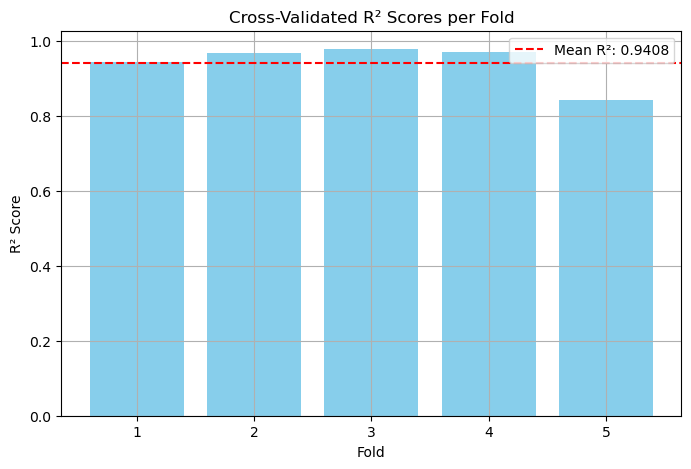

In [16]:
# CV scores
r2_scores = [0.94299856, 0.96782789, 0.97876945, 0.97103957, 0.84317605]

# Plot R² scores for each fold to visually inspect model consistency
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(r2_scores) + 1), r2_scores, color='skyblue')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Mean R²: {np.mean(r2_scores):.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validated R² Scores per Fold')
plt.legend()
plt.grid(True)
plt.show()

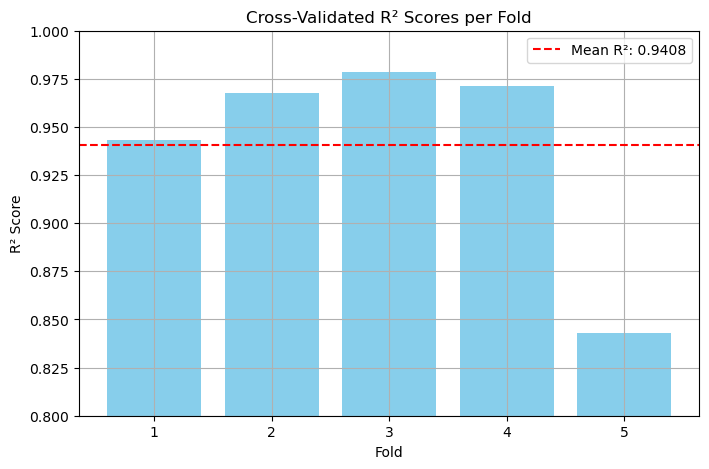

In [17]:
# CV scores
r2_scores = [0.94299856, 0.96782789, 0.97876945, 0.97103957, 0.84317605]

# Plot R² scores for each fold to visually inspect model consistency
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(r2_scores) + 1), r2_scores, color='skyblue')
plt.axhline(np.mean(r2_scores), color='red', linestyle='--', label=f'Mean R²: {np.mean(r2_scores):.4f}')
plt.ylim(0.8, 1.0)
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validated R² Scores per Fold')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# --- Feature importance from CatBoost ---

# Get feature importance with readable format
cat_reg_f.get_feature_importance(prettified=True)

,Feature Id,Importances
0,H,64.071656
1,albedo,30.784477
2,a,1.643012
3,n,1.027379
4,n_obs_used,0.508379
5,moid,0.378015
6,i,0.234671
7,sigma_a,0.186593
8,data_arc,0.160047
9,tp,0.145561


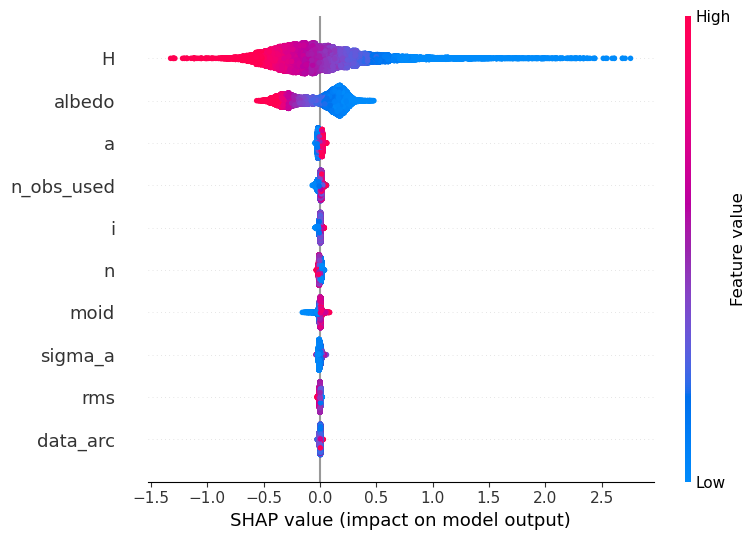

In [19]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 10 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=10)

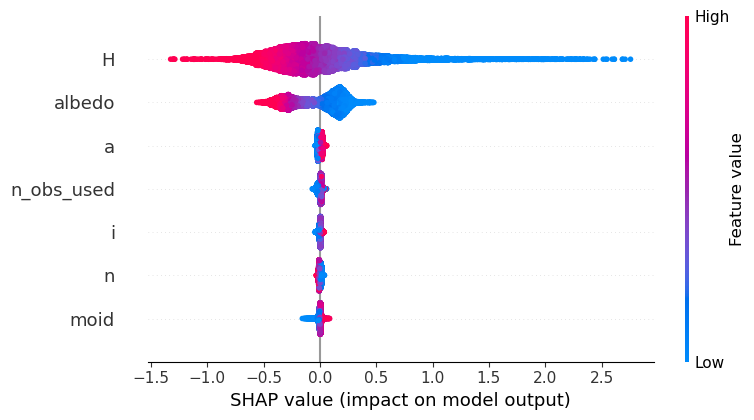

In [21]:
# --- SHAP analysis for model explainability ---

# Initialize SHAP explainer for the trained CatBoost model
explainer = shap.TreeExplainer(cat_reg_f)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Plot summary of SHAP values showing top 7 features impacting predictions
shap.summary_plot(shap_values, X_test, max_display=7)

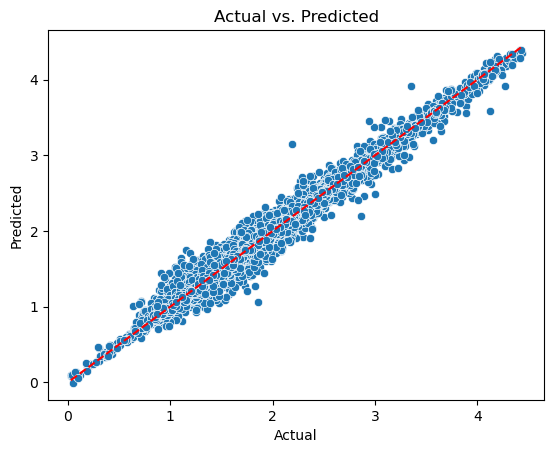

In [22]:
# --- Actual vs Predicted plots ---

# Plot predicted vs actual values on log-transformed scale
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

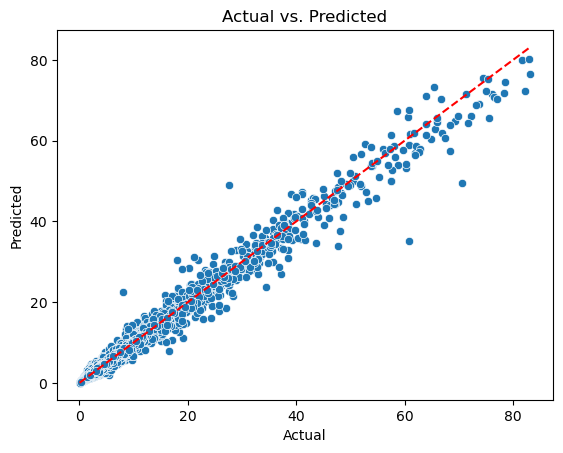

In [23]:
# Plot predicted vs actual values on original scale (inverse transformed)
sns.scatterplot(x=y_test_original, y=y_pred_original)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

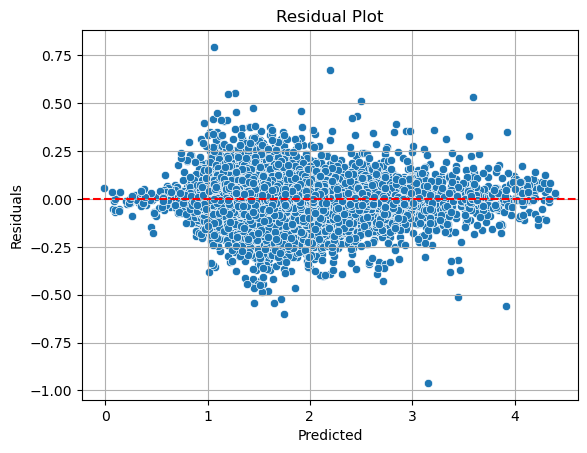

In [24]:
# --- Residual plots to diagnose errors ---

# Residuals on log-transformed scale
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

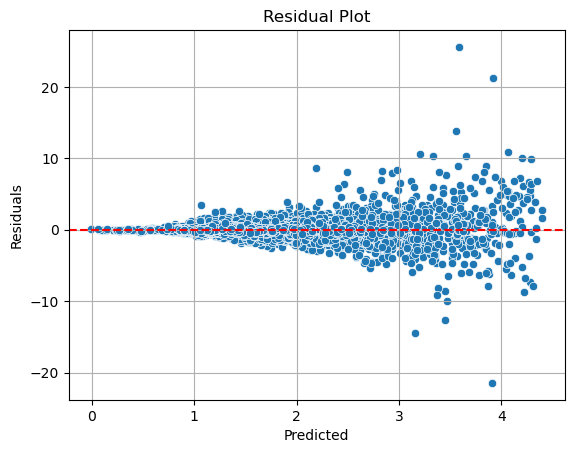

In [25]:
# Residuals on original scale
residuals = y_test_original - y_pred_original

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

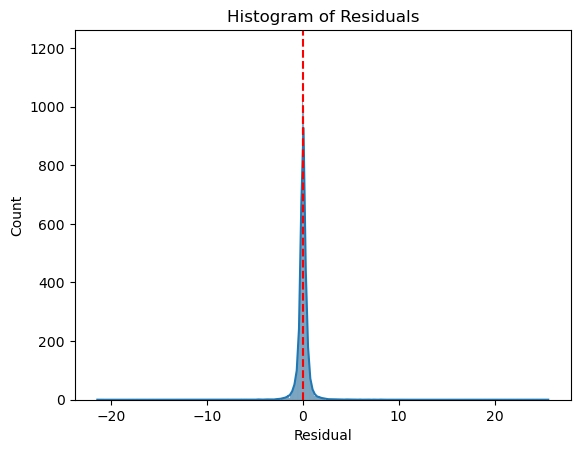

In [26]:
residuals = y_test_original - y_pred_original

sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.show()

#### Checking with quantile regression on catboost

In [27]:
# Quantile regression 0.1 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.1',
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=6,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.0679881	total: 20.9ms	remaining: 41.9s
500:	learn: 0.0132366	total: 3.74s	remaining: 11.2s
1000:	learn: 0.0127179	total: 7.35s	remaining: 7.33s
1500:	learn: 0.0124370	total: 10.9s	remaining: 3.62s
1999:	learn: 0.0122939	total: 14.3s	remaining: 0us
Train Mean Squared Error: 0.0133, R² Score: 0.9462
Test  Mean Squared Error: 0.0137, R² Score: 0.9446
Original Scale - Test MSE: 1.1736, R²: 0.9576


In [28]:
# Quantile regression 0.5 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.5',
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=6,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.1764038	total: 10.7ms	remaining: 21.3s
500:	learn: 0.0264538	total: 4.14s	remaining: 12.4s
1000:	learn: 0.0255691	total: 8.2s	remaining: 8.18s
1500:	learn: 0.0250506	total: 12.2s	remaining: 4.04s
1999:	learn: 0.0246802	total: 16.1s	remaining: 0us
Train Mean Squared Error: 0.0056, R² Score: 0.9771
Test  Mean Squared Error: 0.0059, R² Score: 0.9761
Original Scale - Test MSE: 0.5368, R²: 0.9806


In [29]:
# Quantile regression 0.9 alpha

cat_quantile = CatBoostRegressor(
    loss_function='Quantile:alpha=0.9',
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=6,
    random_seed=42,
    verbose=500
)

cat_quantile.fit(X_train, y_train)

# Predict on test and train set
y_pred = cat_quantile.predict(X_test)
y_train_pred = cat_quantile.predict(X_train)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics (already computed)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Print both
print(f"Train Mean Squared Error: {train_mse:.4f}, R² Score: {train_r2:.4f}")
print(f"Test  Mean Squared Error: {test_mse:.4f}, R² Score: {test_r2:.4f}")

# Inverse transform
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Metrics on original scale
test_mse_original = mean_squared_error(y_test_original, y_pred_original)
test_r2_original = r2_score(y_test_original, y_pred_original)

print(f"Original Scale - Test MSE: {test_mse_original:.4f}, R²: {test_r2_original:.4f}")

0:	learn: 0.0987639	total: 10.2ms	remaining: 20.4s
500:	learn: 0.0118314	total: 3.83s	remaining: 11.5s
1000:	learn: 0.0113714	total: 7.58s	remaining: 7.57s
1500:	learn: 0.0112661	total: 11.1s	remaining: 3.7s
1999:	learn: 0.0112037	total: 14.5s	remaining: 0us
Train Mean Squared Error: 0.0127, R² Score: 0.9483
Test  Mean Squared Error: 0.0129, R² Score: 0.9476
Original Scale - Test MSE: 1.1987, R²: 0.9567
